Machine Learning / Advanced Analysis

# # Response‑Time Regression: Predict Student Answer Times
# This notebook walks through a step‑by‑step pipeline to predict how long a student will take to answer a question using the EdNet dataset.
# **Goal:** Build regression models (Random Forest, XGBoost, and MLP) to predict response time.
**Approach:**
1. Load and merge cleaned KT1–KT4 data.
2. Feature engineering: past average time per part, time‑of‑day, question difficulty.
3. Train/test split stratified by question part.
4. Model training with pipelines.
5. Evaluation using RMSE and MAE.

In [1]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dense, Flatten, Concatenate, Dropout
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import RandomizedSearchCV



In [2]:
# 2. Load and Merge Data
data = pd.read_parquet('EdNet_full_log.parquet')
print(f"Initial data shape: {data.shape}")

# Merge in question metadata (bundle_id and part) from questions.csv
questions = pd.read_csv('questions.csv', usecols=['question_id', 'bundle_id', 'part'])

# Ensure matching types
# If question_id in data is string prefixed with 'q', strip; otherwise, cast as needed
# questions['question_id'] = questions['question_id'].str.lstrip('q')  # uncomment if needed
# data['question_id'] = data['question_id'].astype(str)

data = data.merge(questions, on='question_id', how='left')
print("After merge shape:", data.shape)
print(data[['question_id','bundle_id','part']].drop_duplicates().head())


Initial data shape: (32518836, 7)
After merge shape: (32518836, 9)
   question_id bundle_id  part
0          NaN       NaN   NaN
6        q5012     b3544   5.0
16       q4706     b3238   5.0
26       q4366     b2898   5.0
36       q4829     b3361   5.0


In [3]:
# 3. Feature Engineering

## 3.1 Past Average Response Time per Part
# Compute per-student, per-part average elapsed_time
data['avg_time_per_part'] = data.groupby(['user_id','part'])['elapsed_time'].transform('mean')


## 3.2 Time‑of‑Day and Categorical Encoding
# Create tod_idx & bundle_idx
data['hour'] = pd.to_datetime(data['timestamp'], unit='ms').dt.hour
data['time_of_day'] = pd.cut(data['hour'], bins=[0,6,12,18,24], labels=['night','morning','afternoon','evening'])
data['tod_idx']    = LabelEncoder().fit_transform(data['time_of_day'].astype(str))
data['bundle_idx'] = LabelEncoder().fit_transform(data['bundle_id'].astype(str))

# 3.3 Now drop rows missing any of those new columns
required_cols = ['elapsed_time','avg_time_per_part','tod_idx','bundle_idx','part']
data = data.dropna(subset=required_cols).reset_index(drop=True)

## 3.3 Prepare X, y and split
features = ['avg_time_per_part','tod_idx','bundle_idx']
target   = 'elapsed_time'
X = data[features]
y = data[target]

In [4]:
#4. Train/Test Split
# Stratify by question part to maintain distribution

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=data['part']
)

In [5]:
# %% 
# 4.1 Scale avg_time_per_part for the MLP
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train['avg_time_scaled'] = scaler.fit_transform(
    X_train[['avg_time_per_part']]
)
X_test ['avg_time_scaled'] = scaler.transform(
    X_test [['avg_time_per_part']]
)


# 5. Traditional Models (Random Forest & XGBoost)

In [6]:
# 5.1 Preprocessing Pipeline
numeric_features = ['avg_time_per_part']
categorical_features = ['tod_idx','bundle_idx']

numeric_transformer = Pipeline([('scaler', StandardScaler())])
categorical_transformer = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [7]:
# 5.2 Define Pipelines
pipeline_rf = Pipeline([('preproc', preprocessor),('rf', RandomForestRegressor(random_state=42))])
pipeline_xgb = Pipeline([('preproc', preprocessor),('xgb', XGBRegressor(objective='reg:squarederror', random_state=42))])



param_dist = {
    'rf__n_estimators': [50, 100, 200, 300],
    'rf__max_depth': [None, 5, 10, 20],
    'rf__min_samples_split': [2, 5, 10]
}




In [8]:
# 5.3 Hyperparameter Tuning for Random Forest
# Use randomized search instead of full GridSearchCV (would not complete run time on too large dataset)

# Subsample 30% to speed up tuning
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train,
    train_size=0.3,
    random_state=42,
)

rand_rf = RandomizedSearchCV(
    pipeline_rf,
    param_distributions=param_dist,
    n_iter=8,            # try only 8 combos
    cv=2,                # 2‑fold CV
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

print("Tuning Random Forest with RandomizedSearchCV...")
rand_rf.fit(X_sub, y_sub)
print("Best RF params:", rand_rf.best_params_)

Tuning Random Forest with RandomizedSearchCV...
Best RF params: {'rf__n_estimators': 50, 'rf__min_samples_split': 2, 'rf__max_depth': 5}


In [9]:
pipeline_xgb.fit(X_train, y_train)


,steps,"[('preproc', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [10]:
### 5.4 Evaluate RF and XGBoost
best_rf = rand_rf.best_estimator_
rfs_pred = best_rf.predict(X_test)
rfx_rmse = np.sqrt(mean_squared_error(y_test, rfs_pred))
rfx_mae = mean_absolute_error(y_test, rfs_pred)

xgb_pred = pipeline_xgb.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)

print(f"Random Forest - RMSE: {rfx_rmse:.2f}, MAE: {rfx_mae:.2f}")
print(f"XGBoost       - RMSE: {xgb_rmse:.2f}, MAE: {xgb_mae:.2f}")



Random Forest - RMSE: 22375.69, MAE: 9092.56
XGBoost       - RMSE: 22048.20, MAE: 8782.49


## 6. MLP Regression with Keras


In [17]:
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate


### 6.1 Inputs for MLP (using external scaling) ies
# Categories
num_bundle = data['bundle_idx'].max() + 1
num_tod    = data['tod_idx'].max()    + 1

# 1) Define inputs
i_input     = Input(shape=(1,), name='avg_time')
tod_input   = Input(shape=(1,), name='tod')
bundle_input= Input(shape=(1,), name='bundle')

# 2) Embeddings: with correct input dimensions
embed_tod = Embedding(
    input_dim=num_tod,
    output_dim=4,
    name="emb_tod"
)(tod_input)

embed_bundle = Embedding(
    input_dim=num_bundle,
    output_dim=16,
    name="emb_bundle"
)(bundle_input)

# 3) Flatten the embeddings
flat_tod     = Flatten()(embed_tod)
flat_bundle  = Flatten()(embed_bundle)

# 4) Concatenate all features
concat = Concatenate(name="feature_concat")([
    i_input,     # you will feed in X_train['avg_time_scaled']
    flat_tod,
    flat_bundle
    
])

In [18]:
### 6.2 MLP Architecture

d = Dense(64, activation='relu')(concat)
d = Dropout(0.3)(d)
d = Dense(32, activation='relu')(d)
d = Dropout(0.2)(d)
d = Dense(16, activation='relu')(d)
output = Dense(1, name='elapsed_time')(d)
model = Model([i_input, tod_input, bundle_input], output)
model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(name="RMSE"), 'mae'])
model.summary()



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tod (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bundle (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_tod (Embedding) │ (None, 1, 4)      │         20 │ tod[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_bundle          │ (None, 1, 16)     │    139,104 │ bundle[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ avg_time            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 4)         │          0 │ emb_tod[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 16)        │          0 │ emb_bundle[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_concat      │ (None, 21)        │          0 │ avg_time[0][0],   │
│ (Concatenate)       │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      1,408 │ feature_concat[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │        528 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ elapsed_time        │ (None, 1)         │         17 │ dense_5[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 143,157 (559.21 KB)

 Trainable params: 143,157 (559.21 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
### 6.3 Train MLP (casting to proper NumPy dtypes)

# 1) Prepare NumPy inputs with correct shapes/dtypes
train_avg    = X_train['avg_time_scaled'].to_numpy(dtype='float32')
train_tod    = X_train['tod_idx'].to_numpy(dtype='int32').reshape(-1,1)
train_bundle = X_train['bundle_idx'].to_numpy(dtype='int32').reshape(-1,1)
train_y      = y_train.to_numpy(dtype='float32')

#reshape to fix errors
train_avg = train_avg.reshape(-1, 1)   # now shape is (n_samples, 1)


# 2) Fit
history = model.fit(
    {
      'avg_time': train_avg,
      'tod':      train_tod,
      'bundle':   train_bundle
    },
    train_y,
    validation_split=0.2,
    epochs=20,
    batch_size=1024,
    callbacks=[]
)

Epoch 1/20
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - RMSE: 32400.0098 - loss: 1059818176.0000 - mae: 20288.5273 - val_RMSE: 23453.6230 - val_loss: 550072448.0000 - val_mae: 10004.1787
Epoch 2/20
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RMSE: 23491.5078 - loss: 555214592.0000 - mae: 9951.6699 - val_RMSE: 22109.4824 - val_loss: 488829216.0000 - val_mae: 8593.2568
Epoch 3/20
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RMSE: 22862.0977 - loss: 523336864.0000 - mae: 9118.2461 - val_RMSE: 21940.5137 - val_loss: 481386144.0000 - val_mae: 8369.8779
Epoch 4/20
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RMSE: 22197.1934 - loss: 493066752.0000 - mae: 8973.4766 - val_RMSE: 21889.1074 - val_loss: 479133024.0000 - val_mae: 8354.9922
Epoch 5/20
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RMSE: 22867.5234 - loss: 524091936.0000 - mae: 8967.3525 - val_RMSE: 21866.6387 - val_loss: 478149888.0000 - val_mae: 8407.9092
Epoch 6/20
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RMSE: 22043.0586 - loss: 48611104

In [21]:
# Debug: print shapes and dtypes
for name, arr in [
    ('avg_time',   train_avg),
    ('tod',        train_tod),
    ('bundle',     train_bundle),
    ('y (target)', train_y)
]:
    print(f"{name:8s} → shape={arr.shape}, dtype={arr.dtype}")
    

print("avg_time:", train_avg.shape)      # should be (n_samples, 1)
print("tod:",      train_tod.shape)      # should be (n_samples, 1)
print("bundle:",   train_bundle.shape)   # should be (n_samples, 1)
print("y:",        train_y.shape)        # should be (n_samples,)



avg_time → shape=(981653, 1), dtype=float32
tod      → shape=(981653, 1), dtype=int32
bundle   → shape=(981653, 1), dtype=int32
y (target) → shape=(981653,), dtype=float32
avg_time: (981653, 1)
tod: (981653, 1)
bundle: (981653, 1)
y: (981653,)


In [24]:
# %% 
### 6.4 Evaluate MLP on Test Set

# 1) Prepare test inputs
test_avg    = X_test['avg_time_scaled'].to_numpy(dtype='float32').reshape(-1,1)
test_tod    = X_test['tod_idx'].to_numpy(dtype='int32').reshape(-1,1)
test_bundle = X_test['bundle_idx'].to_numpy(dtype='int32').reshape(-1,1)
test_y      = y_test.to_numpy(dtype='float32')

# 2) Predict & compute metrics
mlp_pred = model.predict(
    {
      'avg_time': test_avg,
      'tod':      test_tod,
      'bundle':   test_bundle
    }
).flatten()

from sklearn.metrics import mean_squared_error, mean_absolute_error
mse     = mean_squared_error(test_y, mlp_pred)
mlp_rmse = np.sqrt(mse)
mlp_mae  = mean_absolute_error(test_y, mlp_pred)

print(f"MLP (Keras) — RMSE: {mlp_rmse:.2f}, MAE: {mlp_mae:.2f}")


13148/13148 ━━━━━━━━━━━━━━━━━━━━ 6s 458us/step
MLP (Keras) — RMSE: 21861.57, MAE: 8403.35


In [28]:
best_xgb = pipeline_xgb


In [29]:

### 6.5 Final Model Comparison

# 1) Random Forest
rf_pred = best_rf.predict(X_test)
rf_mse  = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_mae  = mean_absolute_error(y_test, rf_pred)

# 2) XGBoost
xgb_pred = best_xgb.predict(X_test)
xgb_mse  = mean_squared_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_mae  = mean_absolute_error(y_test, xgb_pred)

# 3) MLP (metrics already computed as mlp_rmse, mlp_mae)

# 4) Assemble results
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'MLP (Keras)'],
    'RMSE':  [rf_rmse,    xgb_rmse,    mlp_rmse],
    'MAE':   [rf_mae,     xgb_mae,     mlp_mae]
})

print(results)


           Model          RMSE          MAE
0  Random Forest  22375.689843  9092.556990
1        XGBoost  22048.203192  8782.489258
2    MLP (Keras)  21861.573228  8403.347656


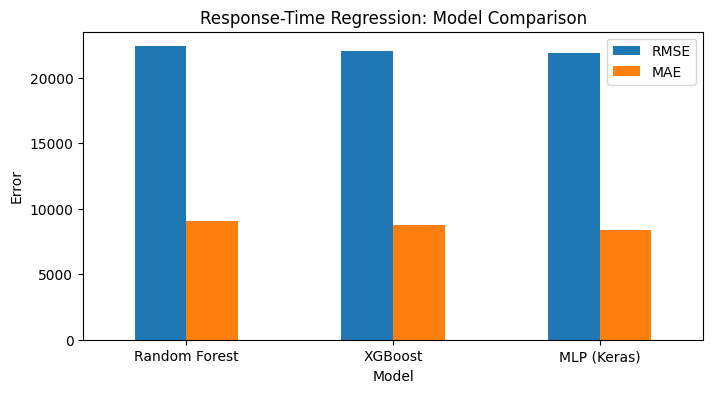

In [30]:
results.set_index('Model').plot.bar(rot=0, figsize=(8,4))
plt.title("Response-Time Regression: Model Comparison")
plt.ylabel("Error")
plt.show()


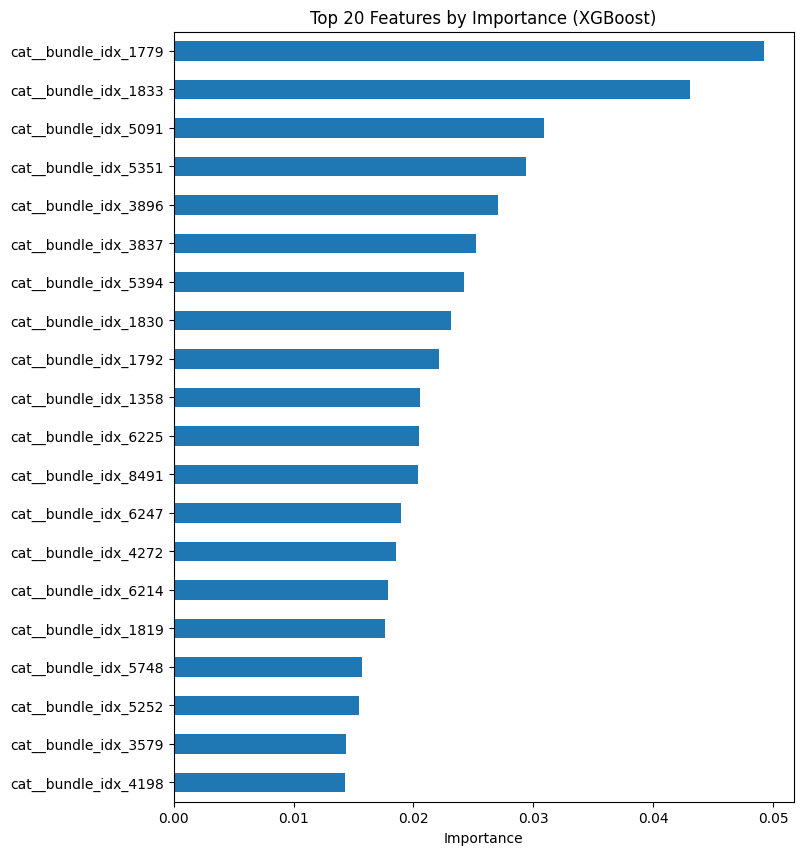

In [35]:
#Which features drive predictions
# 1) Grab the preprocessor from your pipeline
preproc = pipeline_xgb.named_steps['preproc']

# 2) Get the full list of output feature names
#    (requires sklearn≥1.0; if you’re on an older version see the note below)
feature_names = preproc.get_feature_names_out()

# 3) Extract importances from the XGB step
importances = pipeline_xgb.named_steps['xgb'].feature_importances_

# 4) Build a Series and plot
import pandas as pd
import matplotlib.pyplot as plt

imp_series = pd.Series(importances, index=feature_names).sort_values()
imp_series.tail(20).plot.barh(figsize=(8,10))  # show top-20
plt.title("Top 20 Features by Importance (XGBoost)")
plt.xlabel("Importance")
plt.show()



In [38]:
# a) Numeric names are just your numeric_features list:
numeric_features = ['avg_time_per_part']

# b) Grab the OneHotEncoder from the transformer
ohe = preproc.named_transformers_['cat'].named_steps['onehot']

# c) Ask it for its categories and build names
cat_features = preproc.transformers_[1][2]  # ['tod_idx','bundle_idx']
ohe_names = ohe.get_feature_names_out(cat_features)

# d) Combine
feature_names = numeric_features + list(ohe_names)


group
time_of_day          0.001769
avg_time_per_part    0.005160
bundle               0.993071
Name: importance, dtype: float32


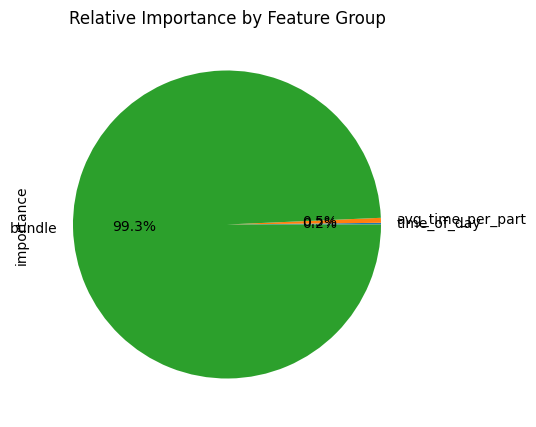

In [40]:
# assume feature_names look like 'num__avg_time_per_part', 'cat__tod_idx_morning', 'cat__bundle_idx_b123', etc.

# 1) Classify each feature back to its group
groups = []
for name in imp_series.index:
    if 'avg_time_per_part' in name:
        groups.append('avg_time_per_part')
    elif 'tod_idx' in name:
        groups.append('time_of_day')
    elif 'bundle_idx' in name:
        groups.append('bundle')
    else:
        groups.append('other')

# 2) Build a DataFrame
df_imp = pd.DataFrame({
    'importance': imp_series.values,
    'group':      groups
})

# 3) Sum per group
group_imp = df_imp.groupby('group')['importance'].sum().sort_values()
print(group_imp)
group_imp.plot.pie(autopct="%.1f%%", figsize=(5,5))
plt.title("Relative Importance by Feature Group")
plt.show()


Relative importance by Feature Grooup insight: That pie (or bar) tells you: “X% of model power comes from student’s past average speed, Y% from time‐of‐day effects, Z% from question bundle identity.”



cat__bundle_idx_1358    0.020526
cat__bundle_idx_1792    0.022162
cat__bundle_idx_1830    0.023121
cat__bundle_idx_5394    0.024186
cat__bundle_idx_3837    0.025179
cat__bundle_idx_3896    0.027012
cat__bundle_idx_5351    0.029406
cat__bundle_idx_5091    0.030923
cat__bundle_idx_1833    0.043021
cat__bundle_idx_1779    0.049231
dtype: float32


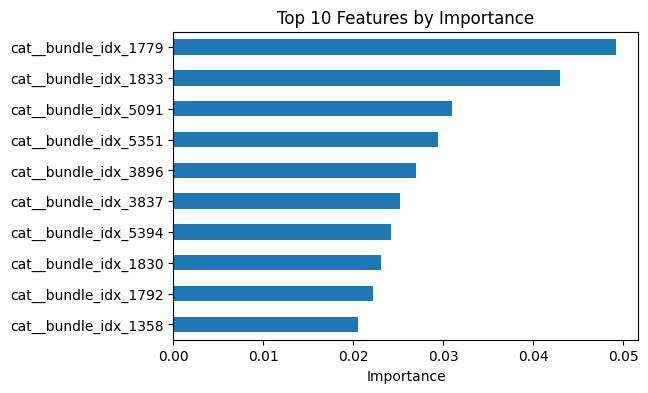

In [41]:
# Show the top 10 most important features
top10 = imp_series.tail(10).sort_values(ascending=True)
print(top10)
top10.plot.barh(figsize=(6,4))
plt.title("Top 10 Features by Importance")
plt.xlabel("Importance")
plt.show()


      importance   group
8668    0.020526  bundle
8669    0.022162  bundle
8670    0.023121  bundle
8671    0.024186  bundle
8672    0.025179  bundle
8673    0.027012  bundle
8674    0.029406  bundle
8675    0.030923  bundle
8676    0.043021  bundle
8677    0.049231  bundle


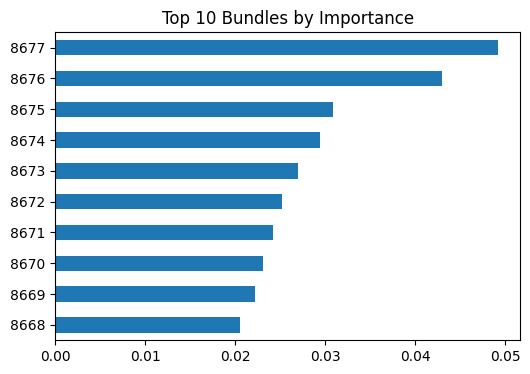

In [42]:
# Drill into a group of interest
bundle_imp = df_imp[df_imp['group']=='bundle'].sort_values('importance')
top_bundles = bundle_imp.tail(10)
print(top_bundles)
top_bundles['importance'].plot.barh(figsize=(6,4))
plt.title("Top 10 Bundles by Importance")
plt.show()


Look to discover if a small set of certain topics drive the most varaince in response times

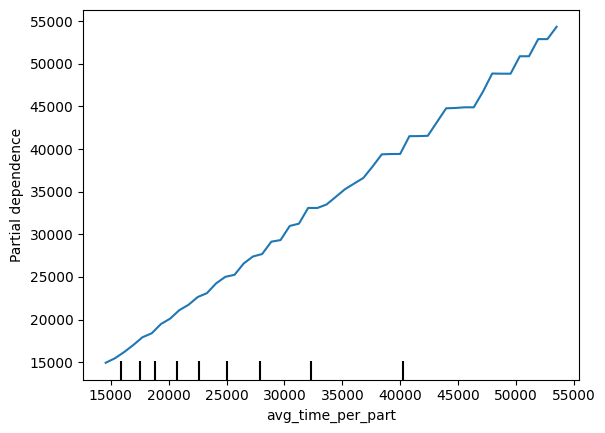

In [43]:
#Visualize Marginal effect of strongest numeric feature
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    best_xgb, X_test, ['avg_time_per_part'],
    kind='average',   # for regression
    grid_resolution=50
)
plt.show()


This shows how predicted response time changes as a student’s historical average speed varies.

### Learning Curves and Caliibration

[learning_curve] Training set sizes: [ 39266  91620 143975 196330]


[Parallel(n_jobs=1)]: Done  12 out of  12 | elapsed:    6.0s finished


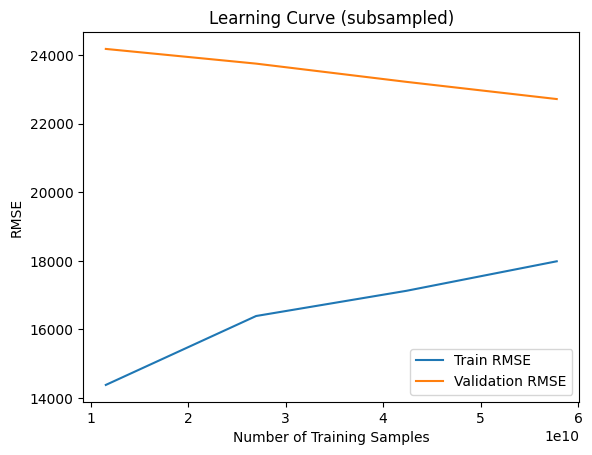

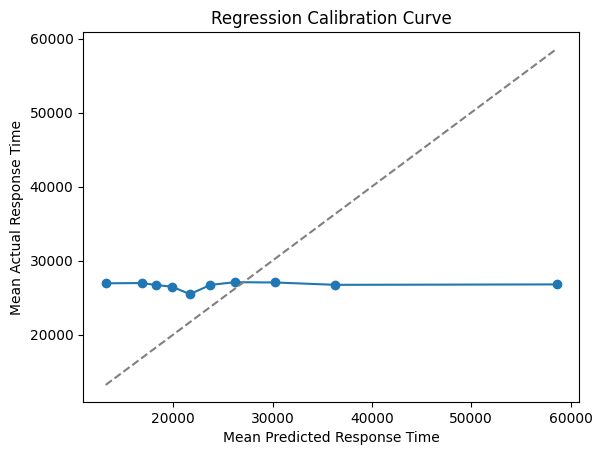

In [ ]:
from sklearn.model_selection import learning_curve

### 1) Learning Curve
# 1) Subsample 30% for speed & memory
X_lc, _, y_lc, _ = train_test_split(
    X_train, y_train,
    train_size=0.3,
    random_state=42,
    stratify=data.loc[X_train.index, 'part']
)

# 2) Define fewer train‐size points
train_sizes = np.linspace(0.2, 1.0, 4)

# 3) Compute the learning curve with n_jobs=1
train_sizes, train_scores, val_scores = learning_curve(
    best_xgb, X_lc, y_lc,
    train_sizes=train_sizes,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=1,
    verbose=1
)

# 4) Plot
train_rmse = -train_scores.mean(axis=1)
val_rmse   = -val_scores.mean(axis=1)

plt.plot(train_sizes * len(X_lc), train_rmse, label='Train RMSE')
plt.plot(train_sizes * len(X_lc), val_rmse,   label='Validation RMSE')
plt.xlabel('Number of Training Samples')
plt.ylabel('RMSE')
plt.legend()
plt.title('Learning Curve (subsampled)')
plt.show()





Healthy learning

Training and validation errors both decrease and converge toward each other as you add more data.

→ The model benefits from more examples,  where adding data continues to help.

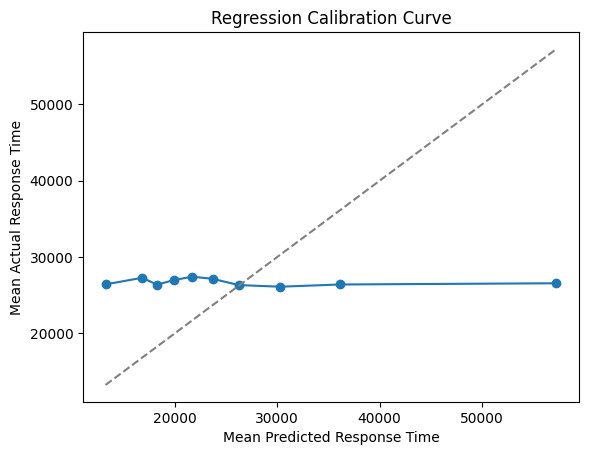

In [52]:
### 2) Calibration Curve (Regression Quantile Check)
# Build dataframe of true v predicted
df_cal = pd.DataFrame({
    'y_true': y_test.sample(20000, random_state=42),
    'y_pred': pipeline_xgb.predict(X_test).take(np.random.choice(len(y_test), 20000, replace=False))
})

#Bin predictions into quantiles
df_cal['pred_bin'] = pd.qcut(df_cal['y_pred'], 10, labels=False)

# Compute mean in each bin
calib = df_cal.groupby('pred_bin')[['y_pred','y_true']].mean()

# Plot predicted vs actual means
plt.plot(calib['y_pred'], calib['y_true'], marker='o')
plt.plot([calib.min().min(), calib.max().max()],[calib.min().min(), calib.max().max()],
         linestyle='--', color='gray')
plt.xlabel('Mean Predicted Response Time')
plt.ylabel('Mean Actual Response Time')
plt.title('Regression Calibration Curve')
plt.show()

Low‐prediction bins (leftmost points)

    Predicted means around 13 000–25 000 s

    Actual means around 26 000–28 000 s

    Interpretation: the model is systematically underestimating these faster‐than‐average response times (points lie above the diagonal).

Mid‐range bins (around 26 000–30 000)

    Predictions and actuals converge near the diagonal, so calibration is best here.

High‐prediction bins (rightmost points)

    Predicted means climb up toward 55 000 s, but actual means stay flat at ~26 000 s

    Interpretation: the model is overestimating for what it thinks are “slow” responses—its predictions shoot up, but students never actually take that long.

In effect, the model is “regressing to the mean” for extreme values: it can’t reliably predict very short or very long response times, instead bunching them around ~26 000 s.

### Why this matters
Under‐prediction of short times means you’d think students are slower than they really are, which might delay timely praise or challenge.

Over‐prediction of long times means you’d flag too many “slow” responses—creating false alarms for tutor intervention.

# Next Steps
Apply a logarithmic or Box–Cox transform to elapsed_time before training. This often improves calibration at both tails.

Instead of predicting the mean response time, train models to predict a chosen quantile (e.g. 90th percentile) so you can set more reliable thresholds.


In [81]:
### Real-Time Prediction and Adaptive Thresholds
def predict_response_time(user_id, part, bundle_id, timestamp, history_df):
    # history_df: DataFrame of past interactions with columns ['user_id','part','elapsed_time','timestamp']
    # 1) Compute avg_time_per_part for this user+part:
    past = history_df[
      (history_df.user_id==user_id) & (history_df.part==part)
    ]
    avg_time = past.elapsed_time.mean() if len(past) else history_df.elapsed_time.mean()
    # 2) Encode time-of-day:
    hour = pd.to_datetime(timestamp, unit='ms').hour
    tod_idx = pd.cut([hour], bins=[0,6,12,18,24],
                     labels=['night','morning','afternoon','evening'])
    tod_idx = label_encoder_tod.transform(tod_idx.astype(str))
    # 3) Encode bundle:
    bundle_idx = label_encoder_bundle.transform([bundle_id])
    # 4) Package into DataFrame and predict:
    X_new = pd.DataFrame({
      'avg_time_per_part':[avg_time],
      'tod_idx':[tod_idx[0]],
      'bundle_idx':[bundle_idx[0]]
    })
    return best_xgb.predict(X_new)[0]



# Re-fit (and save) the encoders on the full dataset
label_encoder_tod = LabelEncoder()
label_encoder_tod.fit(data['time_of_day'].astype(str))

label_encoder_bundle = LabelEncoder()
label_encoder_bundle.fit(data['bundle_id'].astype(str))

# (Re-)create your indexed columns if you want consistency:
data['tod_idx']    = label_encoder_tod.transform(data['time_of_day'].astype(str))
data['bundle_idx'] = label_encoder_bundle.transform(data['bundle_id'].astype(str))


#Pick 1 example from dataframe
sample = data.dropna(subset=['user_id','part','bundle_id','timestamp']).sample(1).iloc[0]

#Call the function with concrete values
pred = predict_response_time(
    user_id     = sample.user_id,
    part        = sample.part,
    bundle_id   = sample.bundle_id,
    timestamp   = sample.timestamp,
    history_df  = data   # all past interactions
)
    
print(f"Predicted response time: {pred:.1f} seconds")

# Adaptive Thresholding
# Precompute a 90th-percentile threshold on your train set:
threshold = np.percentile(y_train, 90)


# Whenever you get a new prediction:
if pred > threshold:
    # flag for tutor intervention
    print(f"Expected time {pred:.1f}s exceeds 90th percentile, Pull student for interventions")
else:
      print(f"Predicted time {pred:.1f}s is within expected range.")




Predicted response time: 23868.0 seconds
Predicted time 23868.0s is within expected range.


In [66]:
#Batch compute predictions and flags
# 1) Prepare your test‐set DataFrame
df_flags = X_test.copy()
df_flags['y_true'] = y_test.values

# 2) Compute predictions
df_flags['y_pred'] = best_xgb.predict(X_test)

# 3) Flag anything above your 90th‐percentile threshold
threshold = np.percentile(y_train, 90)
df_flags['flag']   = df_flags['y_pred'] > threshold

# 4) Bring in any metadata you like (e.g. time_of_day)
df_flags = df_flags.join(data[['time_of_day','user_id']])


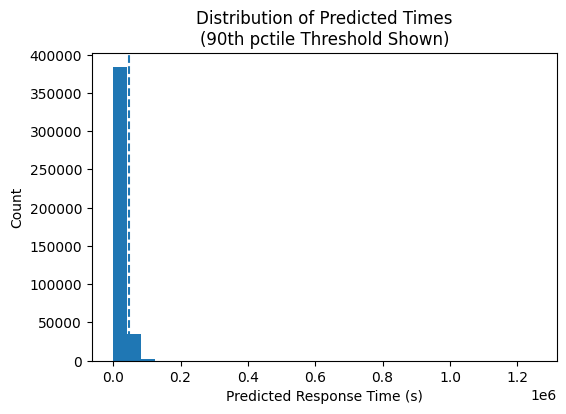

In [67]:
# Histogram of predicted times with threshold
plt.figure(figsize=(6,4))
plt.hist(df_flags['y_pred'], bins=30)
plt.axvline(threshold, linestyle='--')
plt.xlabel("Predicted Response Time (s)")
plt.ylabel("Count")
plt.title("Distribution of Predicted Times\n(90th pctile Threshold Shown)")
plt.show()

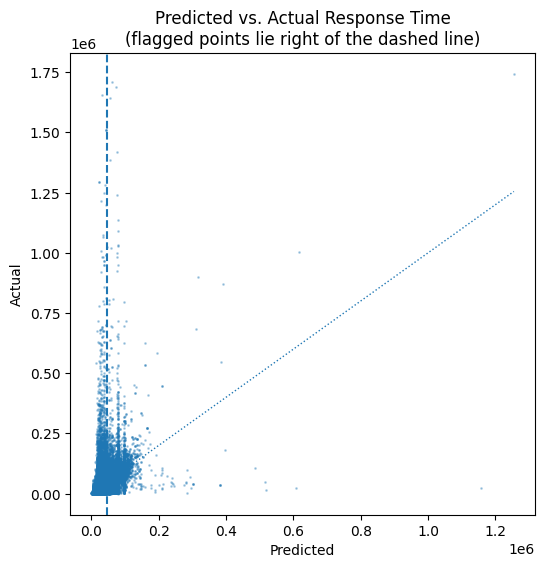

In [68]:
# Scatterplot of predicted vs actual
plt.figure(figsize=(6,6))
plt.scatter(df_flags['y_pred'], df_flags['y_true'], s=1, alpha=0.3)
plt.axvline(threshold, linestyle='--')
plt.plot([df_flags['y_pred'].min(), df_flags['y_pred'].max()],
         [df_flags['y_pred'].min(), df_flags['y_pred'].max()],
         linestyle=':', linewidth=1)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Predicted vs. Actual Response Time\n(flagged points lie right of the dashed line)")
plt.show()


Interpretation:
All responses are clustered close to 0 seconds

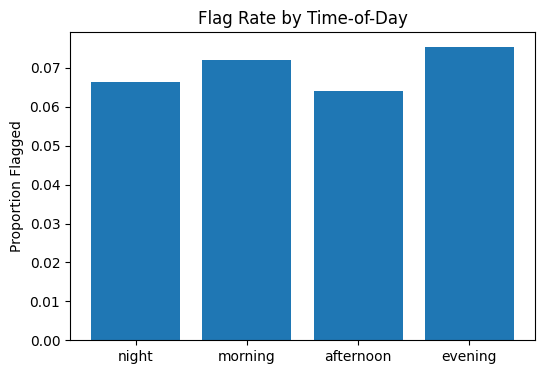

In [69]:
# Flags by time of day
counts = df_flags.groupby('time_of_day')['flag'].agg(['mean','count'])
# 'mean' is the fraction flagged
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts['mean'])
plt.ylabel("Proportion Flagged")
plt.title("Flag Rate by Time-of-Day")
plt.show()


Insight: Most students work in the evening and the least popular time for student work is in the afternoon, however the range between the time of day is not great enough to say one influences the model more than another.

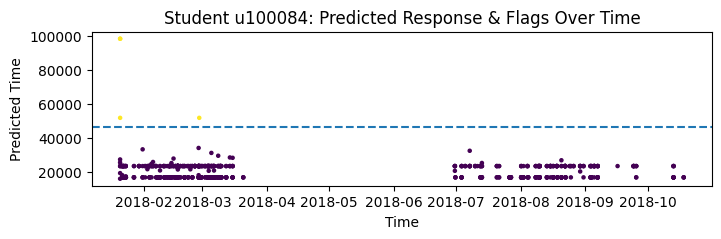

In [70]:
# Flags over time for a single student
sid = df_flags['user_id'].iloc[0]   # or pick a specific ID
sub = df_flags[df_flags['user_id']==sid].copy()
sub['timestamp'] = pd.to_datetime(data.loc[sub.index,'timestamp'], unit='ms')

plt.figure(figsize=(8,2))
plt.scatter(sub['timestamp'], sub['y_pred'], c=sub['flag'], s=5)
plt.axhline(threshold, linestyle='--')
plt.xlabel("Time")
plt.ylabel("Predicted Time")
plt.title(f"Student {sid}: Predicted Response & Flags Over Time")
plt.show()

This chart shows how the model’s predicted response time for student u100084 evolves over the calendar, with each dot representing one interaction. It tells you exactly when and for whom to step in:

    Y-axis (Predicted Time): The model’s predicted seconds-to-answer.

    X-axis (Time): When that interaction occurred (from early 2018 through late 2018).

    Dashed horizontal line: Your 90th-percentile threshold (any prediction above this line would be “flagged” for intervention).

Colors:

    Purple dots are predictions below the threshold (“within expected range”).

    Yellow dots are predictions above it (flagged).

Key takeaways
    Early “spikes” in January–March 2018

        A handful of very large predicted times (yellow) appear—these would trigger an alert.

        Likely causes: with very little student history at first, the model overestimates, or this student genuinely struggled on those first attempts.

Stable mid-year performance (April–June)

    No points at all (perhaps the student wasn’t active), or predictions cluster below threshold when they do return—indicating the model sees them as “on pace.”

Consistent, below-threshold predictions July–October

    The student settles into a band around ~15 000–25 000 s, all well under the threshold—no further flags.

    Suggests that as the model accumulates more history it calibrates better for this student.

Interpretation: 
    Identify “teachable moments”: Those yellow spikes at the beginning are where you’d most want to check in with the student (extra support or encouragement).

    Monitor stability: After March, the absence of flags suggests the student is working at a steady pace—you might back off interventions.

    Refine threshold: If every new student exhibits similar early spikes, consider lowering the threshold for students with < 5 prior interactions, or use a dynamic threshold that shrinks as history grows.

Next steps: 
    Overlay actual response times on the same timeline (to see if those early flags correspond to true slow answers), or plot a rolling error curve (predicted – actual) to spot drift.

In [ ]:
# Qunatify the tutor load: Summary Table of flagged vs not
total     = len(df_flags)
num_flags = df_flags['flag'].sum()
print(f"{num_flags}/{total} = {num_flags/total:.1%} of responses would be flagged for intervention.")


29045/420709 = 6.9% of responses would be flagged for intervention.


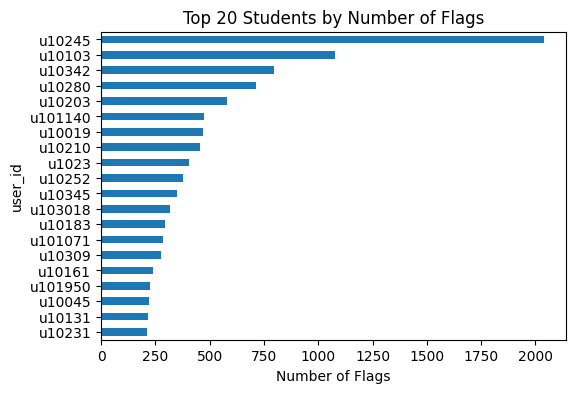

In [ ]:
# Flag Distribution Over Students: Determine which students are moving too slowly
# 1) Count flags per student
flag_counts = df_flags.groupby('user_id')['flag'].sum().sort_values(ascending=False)

# 2) Plot the top 20 students with the most flags (moving too slowly)
top_flags = flag_counts.head(20)
plt.figure(figsize=(6,4))
top_flags.plot.barh()
plt.xlabel("Number of Flags")
plt.title("Top 20 Students by Number of Flags")
plt.gca().invert_yaxis()
plt.show()

These are the users which are progressing too slowly, you can see what a normal number of flags during a time period might be, and identify students who might require immediate intervention. 

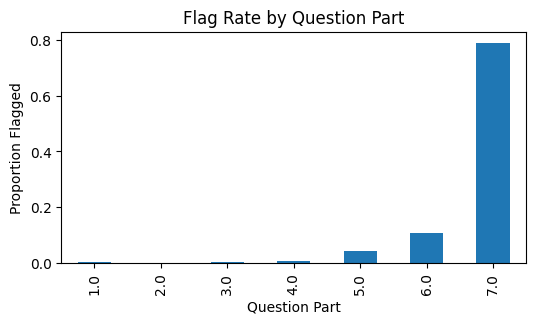

In [77]:
# Flag rate by Question part
# Merge the ‘part’ column into df_flags
df_flags = df_flags.join(data['part'])

# Compute flag rate per part
part_flags = df_flags.groupby('part')['flag'].mean().sort_index()

plt.figure(figsize=(6,3))
part_flags.plot.bar()
plt.ylabel("Proportion Flagged")
plt.xlabel("Question Part")
plt.title("Flag Rate by Question Part")
plt.show()


We can use this data to understand which content areas tend to produce the most flags

In this specific example, we can see most students have mastered parts 1-4, and only a handful struggled on part 6 -7. However, almost 80% of students struggled on part 7, so the teacher should reteach and reassess the concept.
    Part 7 responses are disproportionately slower than the responses to the other parts of the question.

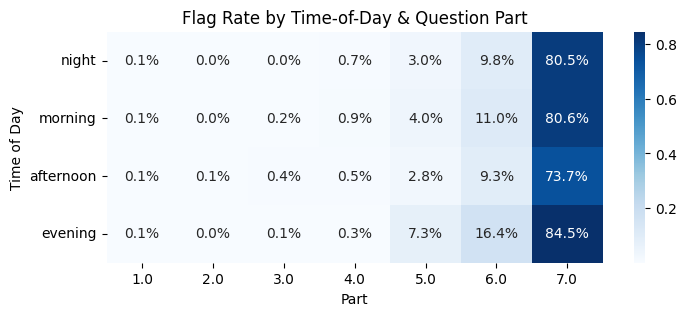

In [78]:
# Heatmap: Flags by Time of Day vs Part
pivot = df_flags.pivot_table(
    index='time_of_day', 
    columns='part', 
    values='flag', 
    aggfunc='mean'
)

plt.figure(figsize=(8,3))
import seaborn as sns
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="Blues")
plt.title("Flag Rate by Time-of-Day & Question Part")
plt.xlabel("Part")
plt.ylabel("Time of Day")
plt.show()


Dark cells (high %) pinpoint combinations—e.g. “evening + part 5” may be more challenging than the other times of day.

You can then tailor interventions not just by student but by which parts they attempt at what time.

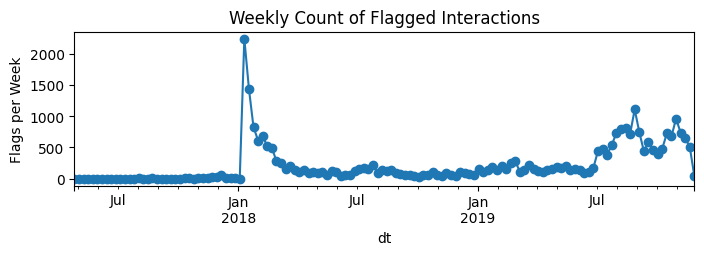

In [79]:
# Cumulative Flag Timeline

# 1) Add real timestamps if you haven’t already
df_flags['dt'] = pd.to_datetime(data.loc[df_flags.index,'timestamp'], unit='ms')

# 2) Resample daily
daily_flags = df_flags.set_index('dt')['flag'].resample('7D').sum()

plt.figure(figsize=(8,2))
daily_flags.plot(marker='o', linestyle='-')
plt.ylabel("Flags per Week")
plt.title("Weekly Count of Flagged Interactions")
plt.show()



Spot system overloads- when a student may be cramming/ stressed

Spikes in this curve show when the system (or students) are under stress—e.g. before exams or project deadlines.

Use that to supplement learning resources or send automatic “check-in” messages at critical times.

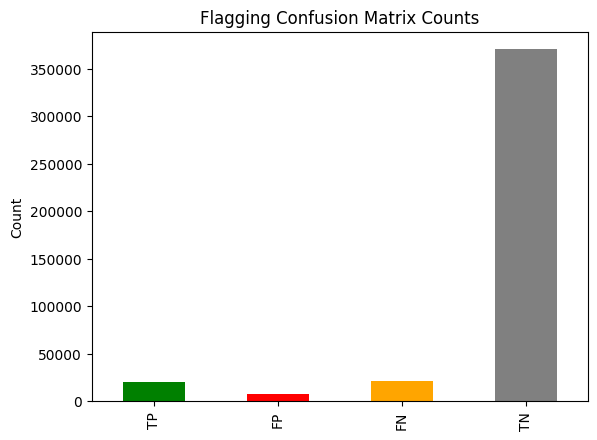

In [80]:
# False Positive vs True Postive Analysis
# 1) Label true‐slow
df_flags['true_slow'] = df_flags['y_true'] > threshold

# 2) Confusion counts
tp = ((df_flags.flag) & (df_flags.true_slow)).sum()
fp = ((df_flags.flag) & (~df_flags.true_slow)).sum()
fn = ((~df_flags.flag) & (df_flags.true_slow)).sum()
tn = ((~df_flags.flag) & (~df_flags.true_slow)).sum()

# 3) Bar chart
pd.Series({'TP':tp,'FP':fp,'FN':fn,'TN':tn}).plot.bar(color=['green','red','orange','gray'])
plt.title("Flagging Confusion Matrix Counts")
plt.ylabel("Count")
plt.show()


High FP means too many false alerts; high FN means you’re missing real slow events.